# Presentación de la situación a resolver

El desafío se basa en ayudar al Sr. Juan a decidir qué tienda de su cadena Alura Store debe vender para iniciar un nuevo emprendimiento. \
Para ello, se analizaran datos de ventas, rendimiento y reseñas de las 4 tiendas de Alura Store. \
El objetivo es identificar la tienda menos eficiente y presentar una recomendación final basada en los datos.

# Importación de datos

In [295]:
import pandas as pd

def cargarDatos() -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Carga los datasets de las tiendas desde archivos locales o URLs de respaldo.

    Return:
    - Tupla con cuatro DataFrames en el orden: tienda1, tienda2, tienda3, tienda4.
    """
    try:
        # Intenta cargar localmente primero.
        print("Función iniciada.")
        print("Cargando archivos localmente.")
        folder_name = "base-de-datos-challenge1-latam/"
        tienda_1 = pd.read_csv(folder_name + "tienda_1.csv")
        tienda_2 = pd.read_csv(folder_name + "tienda_2.csv")
        tienda_3 = pd.read_csv(folder_name + "tienda_3.csv")
        tienda_4 = pd.read_csv(folder_name + "tienda_4.csv")

    except FileNotFoundError:
        # Fallback a URLs (para Colab o si faltan archivos locales).
        print("No fue posible cargar uno o varios archivos locales.")
        print("Cargando archivos remotamente.")
        try: 
            base_url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/"
            tienda_1 = pd.read_csv(base_url + "tienda_1%20.csv")
            tienda_2 = pd.read_csv(base_url + "tienda_2.csv")
            tienda_3 = pd.read_csv(base_url + "tienda_3.csv")
            tienda_4 = pd.read_csv(base_url + "tienda_4.csv")
            print("Archivos cargados remotamente.")
            return tienda_1, tienda_2, tienda_3, tienda_4
        except Exception as e:
            print("No fue posible cargar los datos. Verifique la excepción.")
            print(f'Excepción: {e}')
            
    except Exception as e:
        print("No fue posible cargar los datos. Verifique la excepción.")
        print(f'Excepción: {e}')

    else:
        print("Archivos cargados localmente.")    
        return tienda_1, tienda_2, tienda_3, tienda_4
    
    finally:
        print("Función terminada")

In [296]:
tienda1, tienda2, tienda3, tienda4 = cargarDatos()
tienda1.head()

Función iniciada.
Cargando archivos localmente.
Archivos cargados localmente.
Función terminada


,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,"164,300.00","6,900.00",16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.61,-74.08
1,Mesa de comedor,Muebles,"192,300.00","8,400.00",18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25,-75.56
2,Juego de mesa,Juguetes,"209,600.00","15,900.00",15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.40,-75.51
3,Microondas,Electrodomésticos,"757,500.00","41,000.00",03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.44,-76.52
4,Silla de oficina,Muebles,"335,200.00","20,200.00",07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25,-75.56


## Conozca el conjunto de datos

El objetivo es comparar las 4 tiendas, así que debemos asegurarnos que los DataFrames (DFs) contienen el mismo número de columnas, en el mismo orden y con el mismo tipo de datos.
Como referencia inicial usaremos la Tienda 1.

In [297]:
tienda1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2359 entries, 0 to 2358
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Producto                2359 non-null   object 
 1   Categoría del Producto  2359 non-null   object 
 2   Precio                  2359 non-null   float64
 3   Costo de envío          2359 non-null   float64
 4   Fecha de Compra         2359 non-null   object 
 5   Vendedor                2359 non-null   object 
 6   Lugar de Compra         2359 non-null   object 
 7   Calificación            2359 non-null   int64  
 8   Método de pago          2359 non-null   object 
 9   Cantidad de cuotas      2359 non-null   int64  
 10  lat                     2359 non-null   float64
 11  lon                     2359 non-null   float64
dtypes: float64(4), int64(2), object(6)
memory usage: 221.3+ KB


Ahora sabemos que en teoría cada DF debe tener 12 columnas:
- 4 de tipo float
- 2 de tipo int64
- 6 de tipo obj

Comprobamos que el index (nombre de columna) y orden de las columnas sea el mismo para los 4 DFs mediante el método equals():

In [298]:
tienda1.columns

Index(['Producto', 'Categoría del Producto', 'Precio', 'Costo de envío',
       'Fecha de Compra', 'Vendedor', 'Lugar de Compra', 'Calificación',
       'Método de pago', 'Cantidad de cuotas', 'lat', 'lon'],
      dtype='object')

In [299]:
type(tienda1.columns)

pandas.core.indexes.base.Index

In [300]:
tienda1.columns.equals(tienda2.columns) and \
tienda1.columns.equals(tienda3.columns) and \
tienda1.columns.equals(tienda4.columns)

True

Comprobamos que el tipo de dato de las columnas sea el mismo para los 4 DFs:

In [301]:
tienda1.dtypes

Producto                   object
Categoría del Producto     object
Precio                    float64
Costo de envío            float64
Fecha de Compra            object
Vendedor                   object
Lugar de Compra            object
Calificación                int64
Método de pago             object
Cantidad de cuotas          int64
lat                       float64
lon                       float64
dtype: object

In [302]:
type(tienda1.dtypes)

pandas.core.series.Series

In [303]:
tienda1.dtypes.equals(tienda2.dtypes) \
and tienda1.dtypes.equals(tienda3.dtypes) \
and tienda1.dtypes.equals(tienda4.dtypes)

True

En conclusión, los 4 DFs cuentan con la misma estructura, es decir, mismas columnas, mismo order y mismo tipo de datos.

# Concatenación de DataFrames

Para hacer el análisis más práctico y ahorrarnos una líneas de código, vamos a crear un DF que contenga los datos de todas las tiendas.

Para distinguir un DF de otro, y poder agruparlos en el futuro, vamos a crear una columna que indique a que tienda pertenece y después vamos a concatenar todos los DFs en uno sólo.

In [304]:
tienda1["Tienda"] = 1
tienda2["Tienda"] = 2
tienda3["Tienda"] = 3
tienda4["Tienda"] = 4

In [305]:
tiendas = pd.concat([tienda1, tienda2, tienda3, tienda4])
tiendas

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon,Tienda
0,Asistente virtual,Electrónicos,"164,300.00","6,900.00",16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.61,-74.08,1
1,Mesa de comedor,Muebles,"192,300.00","8,400.00",18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25,-75.56,1
2,Juego de mesa,Juguetes,"209,600.00","15,900.00",15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.40,-75.51,1
3,Microondas,Electrodomésticos,"757,500.00","41,000.00",03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.44,-76.52,1
4,Silla de oficina,Muebles,"335,200.00","20,200.00",07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25,-75.56,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2353,Mesa de comedor,Muebles,"227,700.00","12,600.00",12/02/2020,Camila Rivera,Medellín,5,Tarjeta de crédito,1,6.25,-75.56,4
2354,Silla de oficina,Muebles,"342,000.00","18,600.00",17/05/2022,Felipe Santos,Bucaramanga,5,Tarjeta de crédito,3,7.13,-73.12,4
2355,Vaso térmico,Deportes y diversión,"36,700.00","2,400.00",03/05/2022,Camila Rivera,Bogotá,5,Tarjeta de crédito,1,4.61,-74.08,4
2356,Set de ollas,Artículos para el hogar,"151,800.00","8,300.00",15/06/2020,Blanca Ramirez,Cali,5,Tarjeta de crédito,1,3.44,-76.52,4


Como curiosidad, es posible crear un índice personalizado.

In [306]:
# tienda5 = tienda1.copy()
# tienda5["Tienda"] = 5
# tienda5.index = [f'1-{i}' for i in range(len(tienda5))]
# tienda5

# Tratamiento de valores nulos

Es importante comprobar si nuestro DF consolidado tiene valores nulos, en dado caso, se eliminarán dichos registros.

Notar el mensaje de error.

In [307]:
# tiendas.groupby("Tienda").isnull().sum()

La mejor opción es aplicar apply() para lograr agrupar todos los datos en base al número de "Tienda", y a su vez, dentro de cada tienda agrupar el conteo de los valores nulos por columna.

In [308]:
tiendas.groupby("Tienda").apply(lambda x: x.isnull().sum(), include_groups=False)

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
Tienda,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0


En conclusión, no hay valores nulos, no es necesario ninguna modificación

# Tratamiento de valores inconsistentes

Para mayor facilidad de lectura establecemos un formato que use comas como separadores para datos tipo float.

In [309]:
pd.options.display.float_format = '{:,.2f}'.format

A mi consideración, para saber si un valor es o no inconsistente, sería necesario consultar con un experto en el negocio (Señor Juan) que nos pueda orientar, especialmente si es un dato tipo obj.\
\
Y si es un valor númerico sería bueno saber si hay un domain o límite máximo y mínimo para ese valor.

Por el momento me guiaré con el sentido común, por ejemplo, si "Lugar de Compra" no fuese un lugar real, o si "Precio" tuviese un valor negativo, dichos registros serían eliminados o corregidos.

In [310]:
tiendas.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9435 entries, 0 to 2357
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Producto                9435 non-null   object 
 1   Categoría del Producto  9435 non-null   object 
 2   Precio                  9435 non-null   float64
 3   Costo de envío          9435 non-null   float64
 4   Fecha de Compra         9435 non-null   object 
 5   Vendedor                9435 non-null   object 
 6   Lugar de Compra         9435 non-null   object 
 7   Calificación            9435 non-null   int64  
 8   Método de pago          9435 non-null   object 
 9   Cantidad de cuotas      9435 non-null   int64  
 10  lat                     9435 non-null   float64
 11  lon                     9435 non-null   float64
 12  Tienda                  9435 non-null   int64  
dtypes: float64(4), int64(3), object(6)
memory usage: 1.0+ MB


## Columnas cuantitativas

## 'Precio', 'Costo de envío', 'Calificación', 'Cantidad de cuotas', 'lat', 'lon', 'Tienda'

Para las columnas cuantitativas bastara con usar el método describe():

In [311]:
tiendas.describe()

,Precio,Costo de envío,Calificación,Cantidad de cuotas,lat,lon,Tienda
count,"9,435.00","9,435.00","9,435.00","9,435.00","9,435.00","9,435.00","9,435.00"
mean,"466,732.29","24,875.15",4.01,2.93,5.43,-74.76,2.50
std,"590,320.68","31,480.04",1.39,2.80,2.36,1.21,1.12
min,"7,600.00",0.00,1.00,1.00,-4.22,-77.28,1.00
25%,"55,200.00","3,000.00",3.00,1.00,4.61,-75.56,1.50
50%,"221,500.00","11,700.00",5.00,1.00,4.61,-74.20,2.00
75%,"663,300.00","34,900.00",5.00,4.00,6.25,-74.08,3.00
max,"2,977,000.00","162,500.00",5.00,24.00,11.54,-67.92,4.00


No hay algún outlier o valor atípico apreciable.\
Cabe resaltar que: -90 <= latitud <= 90.\
Cabe resaltar que: -180 <= longitud <= 180.

## Columnas cualitativas

Para la mayoría de columnas cualitativas, simplemente agruparemos sus valores y los contaremos.

### 'Producto'

In [312]:
tiendas.groupby("Producto")["Producto"].value_counts()

Producto
Ajedrez de madera              180
Armario                        197
Asistente virtual              167
Auriculares                    174
Auriculares con micrófono      158
Balón de baloncesto            197
Balón de voleibol              184
Batería                        203
Bicicleta                      196
Bloques de construcción        199
Cama box                       199
Cama king                      201
Carrito de control remoto      206
Celular ABXY                   157
Ciencia de datos con Python    166
Cubertería                     189
Cubo mágico 8x8                180
Cuerda para saltar             186
Dashboards con Power BI        181
Dinosaurio Rex                 175
Estufa                         187
Guitarra acústica              188
Guitarra eléctrica             165
Impresora                      188
Iniciando en programación      195
Iphone 15                      198
Juego de mesa                  175
Kit de bancas                  188
Lavadora de

### 'Categoría del Producto'

In [313]:
tiendas.groupby("Categoría del Producto")["Categoría del Producto"].value_counts()

Categoría del Producto
Artículos para el hogar     730
Deportes y diversión       1113
Electrodomésticos          1149
Electrónicos               1772
Instrumentos musicales      753
Juguetes                   1290
Libros                      742
Muebles                    1886
Name: count, dtype: int64

### 'Fecha de Compra'

La columna "Fecha de Compra" es un caso especial porque queremos saber cuantas fechas son válidas y cuantas no, en cuyo caso las eliminariamos.

Notar que tenemos 9435 registros sin ingún valor nulo.

In [314]:
tiendas["Fecha de Compra"]

0       16/01/2021
1       18/05/2022
2       15/03/2021
3       03/05/2022
4       07/11/2020
           ...    
2353    12/02/2020
2354    17/05/2022
2355    03/05/2022
2356    15/06/2020
2357    17/11/2021
Name: Fecha de Compra, Length: 9435, dtype: object

In [315]:
fechas_convertidas = pd.to_datetime(tiendas["Fecha de Compra"], dayfirst=True)
fechas_convertidas

0      2021-01-16
1      2022-05-18
2      2021-03-15
3      2022-05-03
4      2020-11-07
          ...    
2353   2020-02-12
2354   2022-05-17
2355   2022-05-03
2356   2020-06-15
2357   2021-11-17
Name: Fecha de Compra, Length: 9435, dtype: datetime64[ns]

In [316]:
fechas_convertidas.info()

<class 'pandas.core.series.Series'>
Index: 9435 entries, 0 to 2357
Series name: Fecha de Compra
Non-Null Count  Dtype         
--------------  -----         
9435 non-null   datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 147.4 KB


Notar que seguimos sin tener valores nulos después de la conversión, y que de igual forma los valores máximo y mínimo estan dentro de lo normal.

In [317]:
fechas_convertidas.describe()

count                             9435
mean     2021-08-16 07:36:48.076311808
min                2020-01-01 00:00:00
25%                2020-10-27 00:00:00
50%                2021-08-22 00:00:00
75%                2022-06-04 12:00:00
max                2023-03-31 00:00:00
Name: Fecha de Compra, dtype: object

### 'Vendedor'

In [318]:
tiendas.groupby(["Vendedor"])["Vendedor"].value_counts()

Vendedor
Beatriz Morales    650
Blanca Ramirez     679
Camila Rivera      667
Felipe Santos      701
Izabela de León    744
Juan Fernandez     694
Juliana Costa      677
Lucas Olivera      674
Maria Alfonso      679
Mariana Herrera    656
Pedro Gomez        655
Rafael Acosta      625
Santiago Silva     650
Ángel Rodriguez    684
Name: count, dtype: int64

### 'Lugar de Compra'

In [319]:
tiendas.groupby("Lugar de Compra")["Lugar de Compra"].value_counts()

Lugar de Compra
Armenia            28
Barranquilla      310
Bogotá           3943
Bucaramanga       181
Cali             1007
Cartagena         242
Cúcuta            186
Inírida            14
Leticia           142
Manizales          41
Medellín         2314
Neiva              40
Pasto              94
Pereira           517
Riohacha          163
Santa Marta       151
Soacha             19
Valledupar         14
Villavicencio      29
Name: count, dtype: int64

En mi experiencia, si hubiera valores con algún error ortográfico, tendriamos nombres que se parecerían a otros, pero con conteno más bajo, por ejemplo, "Armenia: 27" y aparte "Armenía: 1".

### 'Método de pago'

In [320]:
tiendas.groupby("Método de pago")["Método de pago"].value_counts()

Método de pago
Cupón                  504
Nequi                 1900
Tarjeta de crédito    6898
Tarjeta de débito      133
Name: count, dtype: int64

A mi consideración no hay datos extraños, por lo que no es necesario realizar un tratamiento o eliminar registros. Pero de ser el caso, probablemente hubiera usado el método de las máscaras para eliminar registros.

# Análisis de datos

## 1. Análisis de facturación



Se calcula el ingreso total de cada tienda

In [321]:
ingreso_total = tiendas.groupby("Tienda")[["Precio"]].sum().sort_values(by="Precio", ascending=False)
ingreso_total

,Precio
Tienda,
1,"1,150,880,400.00"
2,"1,116,343,500.00"
3,"1,098,019,600.00"
4,"1,038,375,700.00"


Idea 1: probablemente para decidir inicialmente que tienda es mejor y cual peor, crearía un DF que ponderara la tienda en base a su posición, en este caso, la tienda 1, al estar en el lugar 1, ponderaría con 3 puntos, mientras que la tienda 4, al estar en la última posición, con 0 puntos.

Idea 2: También podría ponderar cual a sido su curva de crecimiento en base al tiempo, si bien la tienda 1 tiene mayores ventas, se puede deber a que tiene más tiempo abierta que todas la demás

## 2. Ventas por categoría

Se calcula la cantidad de productos vendidos por categoría en cada tienda. La idea es agrupar los datos por categoría y contar el número de ventas de cada tipo, mostrando las categorías más populares de cada tienda.

Notar que: 
- value_counts() siempre devuelve una Serie.
- Convertimos a DF para tener acceso a multiples criterios de orden
- Un DF puede usar multiples criterios en forma de lista para ordenar. En este caso primero ordena por número de 'Tienda' de forma ascendente y después por 'Ventas por Categoría' de forma descendente.

In [322]:
ventas_por_categoria_serie = tiendas.groupby(["Tienda", "Categoría del Producto"])[["Categoría del Producto"]].value_counts()
ventas_por_categoria_df = ventas_por_categoria_serie.to_frame("Ventas por Categoría") 
ventas_por_categoria = ventas_por_categoria_df.sort_values(by=["Tienda","Ventas por Categoría"], ascending=[True,False])
ventas_por_categoria

Ventas por Categoría
Tienda Categoría del Producto                       
1      Muebles                                   465
       Electrónicos                              448
       Juguetes                                  324
       Electrodomésticos                         312
       Deportes y diversión                      284
       Instrumentos musicales                    182
       Libros                                    173
       Artículos para el hogar                   171
2      Muebles                                   442
       Electrónicos                              422
       Juguetes                                  313
       Electrodomésticos                         305
       Deportes y diversión                      275
       Instrumentos musicales                    224
       Libros                                    197
       Artículos para el hogar                   181
3      Muebles                                   499
       Electrónicos                              451
       Juguetes                                  315
       Electrodomésticos                         278
       Deportes y diversión                      277
       Libros                                    185
       Artículos para el hogar                   177
       Instrumentos musicales                    177
4      Muebles                                   480
       Electrónicos                              451
       Juguetes                                  338
       Deportes y diversión                      277
       Electrodomésticos                         254
       Artículos para el hogar                   201
       Libros                                    187
       Instrumentos musicales                    170

## 3. Valoración media por tienda

Se calculan las calificaciones promedio de los clientes para cada tienda. El objetivo es conocer la satisfacción del cliente con los productos vendidos.

In [323]:
calificacion_promedio = tiendas.groupby("Tienda")[["Calificación"]].mean().\
sort_values(by="Calificación", ascending=False)
calificacion_promedio

,Calificación
Tienda,
3,4.05
2,4.04
4,4.00
1,3.98


## 4. Productos más y menos vendidos

Se identifican qué productos fueron los más vendidos y los menos vendidos en cada tienda.

### Productos más vendidos en cada tienda

La razón para aplicar un top 3 fue para solucionar de forma sencilla el caso en el que varios productos cuentan con un empate en su conteo de ventas

In [324]:
ventas_por_producto_top = (
    tiendas.groupby("Tienda")
        .apply(
            lambda tienda: 
                tienda.groupby("Producto", as_index=False)
                .size()
                .nlargest(3, "size")
            ,include_groups=False)      
        .reset_index(level=(1), drop=True)
)
# type(ventas_por_producto)
# ventas_por_producto.index
# ventas_por_producto.columns
ventas_por_producto_top

,Producto,size
Tienda,,
1,Armario,60
1,Microondas,60
1,TV LED UHD 4K,60
2,Iniciando en programación,65
2,Microondas,62
2,Batería,61
3,Kit de bancas,57
3,Cama king,56
3,Mesa de comedor,56


### Productos menos vendidos en cada tienda

In [325]:
ventas_por_producto_bottom = (
    tiendas.groupby("Tienda")
        .apply(
            lambda tienda: 
                tienda.groupby("Producto", as_index=False)
                .size()
                .nsmallest(3, "size")
            ,include_groups=False)      
        .reset_index(level=(1), drop=True)
)
# type(ventas_por_producto)
# ventas_por_producto.index
# ventas_por_producto.columns
ventas_por_producto_bottom

,Producto,size
Tienda,,
1,Auriculares con micrófono,33
1,Celular ABXY,33
1,Olla de presión,35
2,Juego de mesa,32
2,Impresora,34
2,Mesa de comedor,34
3,Bloques de construcción,35
3,Microondas,36
3,Mochila,36


## 5. Valor del envío promedio por tienda

Se calcula el costo de envío promedio para cada tienda. El objetivo es comprender cuánto se gasta, en promedio, en el envío de cada tienda.  Sabiendo que el cliente paga el envío.

In [326]:
costo_envio_promedio = (
    tiendas.groupby("Tienda")[["Costo de envío"]]
    .mean()
    .sort_values(by="Costo de envío", ascending=False))
costo_envio_promedio

,Costo de envío
Tienda,
1,"26,018.61"
2,"25,216.24"
3,"24,805.68"
4,"23,459.46"


# Visualización de datos

In [327]:
import matplotlib.pyplot as plt

Matplotlib es una librería de Python que ofrece una variedad de tipos de gráficos que son fáciles de implementar y personalizar.

## Facturación por tienda

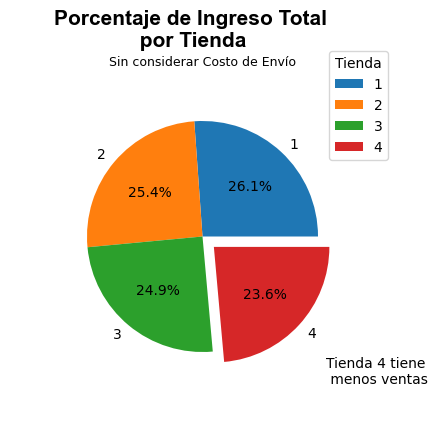

In [328]:
# Ajusta el tamaño general del gráfico.
plt.figure(figsize=(10, 5))

# Cuerpo del gráfico.
plt.pie(x=ingreso_total["Precio"], # array
        labels=ingreso_total.index, # etiquetas
        explode=[0,0,0,0.1], # resalta una porción del pie
        autopct="%1.1f%%", # modifica el formato del %
        radius=0.75) # ajusta el tamaño del pie

# Título de gráfico.
plt.suptitle("Porcentaje de Ingreso Total\n por Tienda",
          fontsize = 15, 
          family = "Arial",
          fontweight = "bold",
          y=0.95)

# Subtítulo.
plt.title("Sin considerar Costo de Envío",
          fontsize=9,
          y=0.925,
          loc="center") # right | left

# Leyenda.
plt.legend(title="Tienda", 
           loc="best") # upper left | lower right

# Anotación simple.
plt.annotate('Tienda 4 tiene\n menos ventas', 
             xy=(0.8, -0.95)) # Ubicación estilo plano cartesiano

plt.show()

Las tienda 4 y 3 son las que facturan menos dinero.

## Calificación por tienda

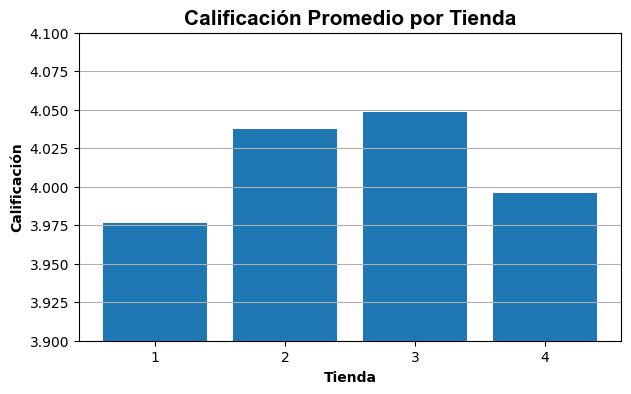

In [329]:
plt.figure(figsize=(7, 4))

plt.bar(x=calificacion_promedio.index,
        height=calificacion_promedio["Calificación"])

plt.grid(axis="y") # Cuadricula

plt.title("Calificación Promedio por Tienda",
          fontsize = 15, 
          family = "Arial",
          fontweight = "bold",     
          loc="center")

# Nombre de ejes.
plt.xlabel("Tienda", 
           fontweight="bold")
plt.ylabel("Calificación", 
           fontweight="bold")

# Escala de ejes
plt.xticks(calificacion_promedio.index) # Escala
plt.ylim((3.9, 4.1)) # Domain

plt.show()

Las tiendas peor valoradas son la 1 y la 4.

## Desempeño de facturación por año

Este análisis en particular empezó porque me pregunte si todas las tiendas llevaban el mismo tiempo abiertas, imagine que tal vez la razón por la que la Tienda 4 factura menos es porque era la más nueva. 

Primero se convierte la columna 'Fecha de Compra' de tipo obj a tipo datetime, ya que este tipo de dato nos permite realizar operaciones especificas con fechas. 

In [330]:
tiendas["Fecha de Compra"] = pd.to_datetime(tiendas["Fecha de Compra"], 
                                            dayfirst=True)
tiendas.head(3)

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon,Tienda
0,Asistente virtual,Electrónicos,"164,300.00","6,900.00",2021-01-16,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.61,-74.08,1
1,Mesa de comedor,Muebles,"192,300.00","8,400.00",2022-05-18,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25,-75.56,1
2,Juego de mesa,Juguetes,"209,600.00","15,900.00",2021-03-15,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.40,-75.51,1


Se crea una nueva columna 'Año de Compra' extrayendo el año de 'Fecha de Compra'.

In [331]:
tiendas["Año de Compra"] = tiendas["Fecha de Compra"].dt.year
tiendas.head(3)

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon,Tienda,Año de Compra
0,Asistente virtual,Electrónicos,"164,300.00","6,900.00",2021-01-16,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.61,-74.08,1,2021
1,Mesa de comedor,Muebles,"192,300.00","8,400.00",2022-05-18,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25,-75.56,1,2022
2,Juego de mesa,Juguetes,"209,600.00","15,900.00",2021-03-15,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.40,-75.51,1,2021


Desde mi punto de vista, para limpiar y modificar datos es mejor usar la **forma larga** de un DF.

In [332]:
tiendas.groupby(["Tienda", "Año de Compra"])[["Precio"]].sum()

Precio
Tienda Año de Compra               
1      2020          368,933,200.00
       2021          362,120,800.00
       2022          316,565,600.00
       2023          103,260,800.00
2      2020          320,466,600.00
       2021          351,215,500.00
       2022          358,226,500.00
       2023           86,434,900.00
3      2020          321,707,500.00
       2021          362,954,400.00
       2022          350,438,300.00
       2023           62,919,400.00
4      2020          330,847,700.00
       2021          347,823,600.00
       2022          302,221,500.00
       2023           57,482,900.00

Sin embargo, para gráficar y entender visualmente mejor los datos, es mejor usar la **forma ancha** de un DF.

In [338]:
tendencia_de_facturacion = tiendas.groupby(["Tienda", "Año de Compra"])[["Precio"]]\
                                    .sum()\
                                    .unstack("Tienda")
tendencia_de_facturacion

Precio                                             
Tienda                     1              2              3              4
Año de Compra                                                            
2020          368,933,200.00 320,466,600.00 321,707,500.00 330,847,700.00
2021          362,120,800.00 351,215,500.00 362,954,400.00 347,823,600.00
2022          316,565,600.00 358,226,500.00 350,438,300.00 302,221,500.00
2023          103,260,800.00  86,434,900.00  62,919,400.00  57,482,900.00

Es importante entender que nuestras columnas son de tipo **Multi-índice**, y nuestros registros o filas son de tip **Índice sencillo**.

In [334]:
tendencia_de_facturacion.columns

MultiIndex([('Precio', 1),
            ('Precio', 2),
            ('Precio', 3),
            ('Precio', 4)],
           names=[None, 'Tienda'])

In [335]:
tendencia_de_facturacion.index

Index([2020, 2021, 2022, 2023], dtype='int32', name='Año de Compra')

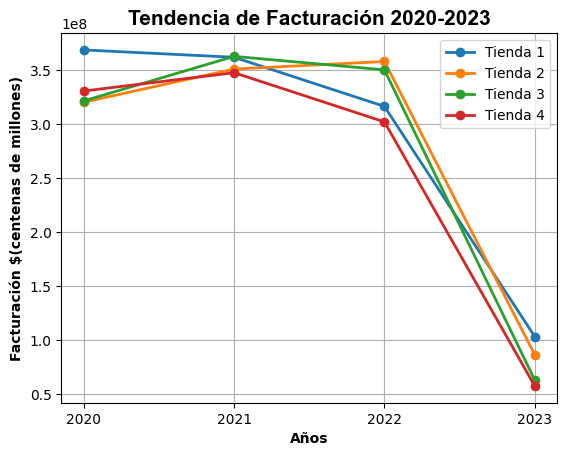

In [339]:
for precio, tienda in tendencia_de_facturacion.columns:
    plt.plot(tendencia_de_facturacion.index, # x
             tendencia_de_facturacion[precio, tienda], #y
             marker='o', 
             linewidth=2, 
             label=f'Tienda {tienda}') # Asigna una leyenda a cada tienda
    
plt.title("Tendencia de Facturación 2020-2023",
          fontsize=15,
          family="Arial",
          fontweight="bold",
          loc="center")

plt.grid()
plt.xticks(tendencia_de_facturacion.index)
plt.yticks()

plt.xlabel("Años",
           fontweight="bold")
plt.ylabel("Facturación $(centenas de millones)",
           fontweight="bold")
plt.legend()

La razón por la que la transición 2022-2023 tiene una inclinación negativa, que a simple vista pudiera parecer que las ventas se desplomaron de un año para otro es porque las ventas del año 2023 no abarcan todos los meses, sólo unos cuantos.

Inclusive así, se puede notar que el desempeño en cuanto a facturación de la Tienda 4 a lo largo de los años ha sido inferior a la mayoría del tiempo, refutando así, que las poca facturación de la tienda 4 se debiese a que es una tienda relativamente nueva.

## Informe Final

El señor Juan quiere saber cual de las 4 Tiendas de su cadena Alura Store debe vender para iniciar un nuevo emprendimiento.

La sección de 'Visualización de datos' demostró que la Tienda 4 es la que menos factura de forma total y su desempeño casi siempre esta por debajo de las demás cada año. \
\
De igual forma la calificación promedio de la Tienda 4 esta por debajo de las Tiendas 2 y 3, siendo el tercer lugar, y a pesar de que la Tienda 1 esta peor calificada que la Tienda 4, la 1 destaca por ser la que factura más que todas.

Debido a dichas razones, **la sugerencia es vender la Tienda 4**.